# Task 5 — Scikit-Learn e scelta del modello finale

Confronto fra piu' classificatori, tuning, scelta finale. La sezione 8 mostra la procedura pronta
Motivazioni: `documentation/05_modellazione.md`.

In [1]:
# REGOLA 1 DEL TASK: il test set si mette da parte SUBITO e non si tocca fino alla
# sezione 7. Ogni scelta — modelli, scaler, feature, iperparametri, soglia — si fa in
# 5-fold cross-validation sul solo training set. E' la regola che il Task 4 ha mostrato
# necessaria: scegliere e misurare sugli stessi dati restituisce il massimo di un insieme
# di rumore, non una stima delle prestazioni.
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, GridSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, QuantileTransformer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)

sns.set_theme(style="whitegrid")
SEME = 42

training = pd.read_csv("../data/training.csv").set_index("USERID")
y, X = training["ABBANDONO"], training.drop(columns="ABBANDONO")
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, stratify=y, random_state=SEME)
CV = StratifiedKFold(5, shuffle=True, random_state=SEME)

print(f"training set: {len(y_tr)} studenti (positivi {y_tr.mean():.1%})")
print(f"test set    : {len(y_te)} studenti (positivi {y_te.mean():.1%})")

training set: 5628 studenti (positivi 57.7%)
test set    : 1407 studenti (positivi 57.7%)


## 1. Protocollo

Divisione 80/20 stratificata. Il test set si mette da parte **subito** e non si tocca fino alla
sezione 7: ogni scelta si fa in cross-validation sul solo training set.

Due riferimenti: baseline «sempre abbandona» **0,5771**, miglior classificatore manuale (Task 4)
**0,7933**. Il secondo dice quanto valga usare Scikit-Learn invece delle venti righe del Task 2.

In [2]:
# I due riferimenti contro cui va letto ogni numero del task: la baseline che risponde
# sempre "abbandona" e il miglior classificatore manuale del Task 4. Il secondo e' il piu'
# interessante, perche' dice quanto valga usare Scikit-Learn invece di venti righe scritte
# a mano.
baseline = cross_validate(DummyClassifier(strategy="most_frequent"), X_tr, y_tr, cv=CV,
                          scoring="accuracy")["test_score"]
MANUALE_T4 = 0.7933          # miglior configurazione del Task 4 (NB, soglie dalle medie di classe)

print(f"baseline (classe maggioritaria)        : {baseline.mean():.4f}")
print(f"miglior classificatore manuale (Task 4): {MANUALE_T4:.4f}")

baseline (classe maggioritaria)        : 0.5771
miglior classificatore manuale (Task 4): 0.7933


## 2. I classificatori in gara

I cinque modelli visti a lezione, con **parametri di default**, per avere un punto di partenza non
influenzato dalle nostre scelte. Il k-NN parte dal k predefinito di Scikit-Learn, 5.

Lo scaling sta **dentro la `Pipeline`**, cosi' media e deviazione standard si stimano sulle sole
pieghe di addestramento.

In [3]:
# I cinque modelli visti a lezione, con PARAMETRI DI DEFAULT, per avere un punto di
# partenza non influenzato dalle nostre scelte.
# REGOLA 2 DEL TASK: lo scaling sta dentro una Pipeline, mai applicato prima. Cosi' media e
# deviazione standard vengono stimate sulle sole pieghe di addestramento e non filtra
# informazione dalla piega di validazione. Il decision tree non lo usa: e' invariante a
# trasformazioni monotone delle feature, quindi per lui lo scaler non cambia nulla.
def con_scaling(modello, scaler=None):
    return Pipeline([("scala", scaler or StandardScaler()), ("modello", modello)])

modelli = {
    "Perceptron":            con_scaling(Perceptron(random_state=SEME)),
    "Regressione logistica": con_scaling(LogisticRegression(max_iter=1000, random_state=SEME)),
    "k-NN":                  con_scaling(KNeighborsClassifier()),
    "Naive Bayes gaussiano": con_scaling(GaussianNB()),
    "Decision tree":         DecisionTreeClassifier(random_state=SEME),
}

righe = {}
for nome, modello in modelli.items():
    r = cross_validate(modello, X_tr, y_tr, cv=CV, scoring=["accuracy", "f1", "roc_auc"], n_jobs=-1)
    righe[nome] = {"accuratezza": r["test_accuracy"].mean(), "dev.std": r["test_accuracy"].std(),
                   "F1": r["test_f1"].mean(), "ROC-AUC": r["test_roc_auc"].mean()}
confronto = pd.DataFrame(righe).T.sort_values("accuratezza", ascending=False)
confronto.round(4)

,accuratezza,dev.std,F1,ROC-AUC
Regressione logistica,0.8074,0.0095,0.8389,0.8683
Naive Bayes gaussiano,0.7944,0.0086,0.8232,0.8610
k-NN,0.7839,0.0073,0.8173,0.8310
Perceptron,0.7228,0.0683,0.7691,0.7763
Decision tree,0.7178,0.0191,0.7537,0.7108


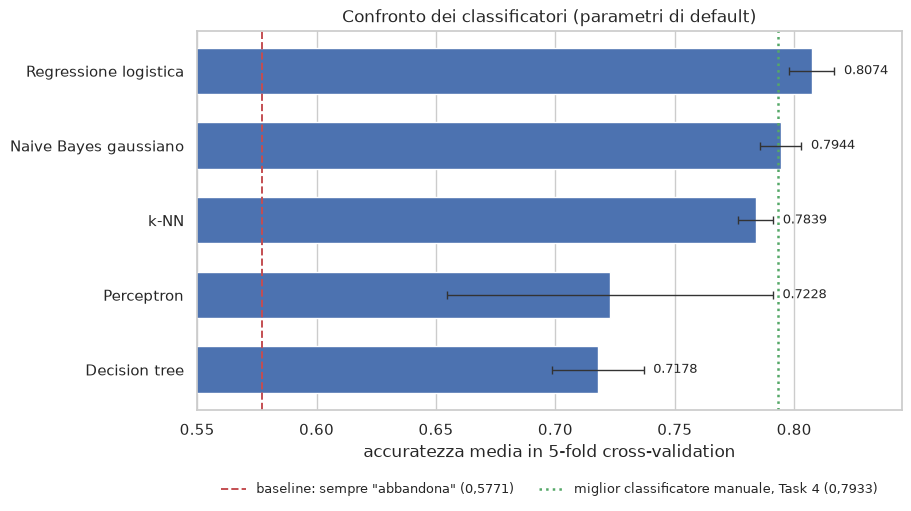

In [4]:
# Le barre d'errore sono la deviazione standard fra le pieghe: senza, i confronti non si leggono.
s = confronto["accuratezza"].sort_values()
fig, ax = plt.subplots(figsize=(9, 5.0), constrained_layout=True)
ax.barh(s.index, s.values, xerr=confronto.loc[s.index, "dev.std"], color="#4C72B0", height=.62,
        error_kw=dict(ecolor="#333", capsize=3, lw=1))
for i, (k, v) in enumerate(s.items()):
    ax.text(v + confronto.loc[k, "dev.std"] + .004, i, f"{v:.4f}", va="center", fontsize=9)
ax.axvline(baseline.mean(), color="#C44E52", ls="--", lw=1.4, label='baseline: sempre "abbandona" (0,5771)')
ax.axvline(MANUALE_T4, color="#55A868", ls=":", lw=1.8, label="miglior classificatore manuale, Task 4 (0,7933)")
ax.set_xlim(.55, .845); ax.set_xlabel("accuratezza media in 5-fold cross-validation")
ax.set_title("Confronto dei classificatori (parametri di default)")
ax.legend(loc="upper center", bbox_to_anchor=(.5, -.16), ncol=2, fontsize=9, frameon=False)
ax.grid(axis="y", visible=False)
plt.show()

**Tre modelli su cinque fanno peggio del classificatore manuale del Task 4** (0,7933): solo la
regressione logistica lo supera, il Naive Bayes lo eguaglia. Scikit-Learn non regala niente.

Il decision tree senza limiti e' il peggiore di tutti (0,7178), sotto perfino al Perceptron: un albero
lasciato crescere memorizza il training set. Il Perceptron ha deviazione standard 0,0683, sette volte
quella della regressione logistica — i dati non sono linearmente separabili e la soluzione dipende
dalla piega.

## 3. Le due domande lasciate aperte dal Task 3

In [5]:
# Prima domanda lasciata aperta dal Task 3: le code pesanti richiedono uno scaler robusto?
# Si provano solo i due modelli a cui lo scaling serve davvero, uno basato sul gradiente e
# uno sulle distanze. La risposta sara' NO — il suggerimento del Task 3 era sbagliato, e
# lo diciamo invece di nasconderlo.
scalatori = {"StandardScaler": StandardScaler(), "RobustScaler": RobustScaler(),
             "QuantileTransformer": QuantileTransformer(output_distribution="normal", random_state=SEME)}
prove = {}
for nome, base in [("Regressione logistica", LogisticRegression(max_iter=1000, random_state=SEME)),
                   ("k-NN", KNeighborsClassifier())]:
    prove[nome] = {ns: cross_validate(con_scaling(base, s), X_tr, y_tr, cv=CV,
                                      scoring="accuracy", n_jobs=-1)["test_score"].mean()
                   for ns, s in scalatori.items()}
print("### quale scaler")
print(pd.DataFrame(prove).T.round(4).to_string())

### quale scaler
                       StandardScaler  RobustScaler  QuantileTransformer
Regressione logistica          0.8074        0.8074               0.7987
k-NN                           0.7839        0.7816               0.7845


In [6]:
# Seconda domanda del Task 3: servono le tre feature quasi prive di segnale? Il confronto
# e' APPAIATO, piega per piega: la differenza e' di pochi millesimi, quindi conta se il
# segno e' sistematico (5/5 pieghe) o cambia da una piega all'altra (rumore).
INERTI = ["feature1_media", "feature2_media", "feature3_media"]
print("### servono le tre feature che il Task 3 aveva dichiarato prive di segnale?")
for nome in ["Regressione logistica", "k-NN", "Decision tree"]:
    m = modelli[nome]
    tutte   = cross_validate(m, X_tr, y_tr, cv=CV, scoring="accuracy", n_jobs=-1)["test_score"]
    ridotte = cross_validate(m, X_tr.drop(columns=INERTI), y_tr, cv=CV, scoring="accuracy", n_jobs=-1)["test_score"]
    d = tutte - ridotte
    print(f"  {nome:<24} 8 feature {tutte.mean():.4f}   5 feature {ridotte.mean():.4f}   "
          f"differenza {d.mean():+.4f}  ({int((d > 0).sum())}/5 pieghe a favore di 8)")

### servono le tre feature che il Task 3 aveva dichiarato prive di segnale?
  Regressione logistica    8 feature 0.8074   5 feature 0.8047   differenza +0.0027  (5/5 pieghe a favore di 8)
  k-NN                     8 feature 0.7839   5 feature 0.7850   differenza -0.0011  (2/5 pieghe a favore di 8)


  Decision tree            8 feature 0.7178   5 feature 0.7168   differenza +0.0011  (3/5 pieghe a favore di 8)


**Due risultati scomodi, riportati lo stesso.**

Lo scaler resistente agli outlier **non cambia niente**: `RobustScaler` da' alla regressione logistica
lo stesso identico punteggio e al k-NN due millesimi in meno. Il suggerimento del Task 3 era
ragionevole ma sbagliato su questi dati — gli outlier sono poche decine su 7.035.

Sulle tre feature «inerti» la risposta **dipende dal modello**, ed e' questo il punto. Per la
regressione logistica — il modello che verra' scelto — toglierle peggiora il punteggio in **5 pieghe
su 5**: contribuiscono. Per k-NN e decision tree la differenza e' di un millesimo scarso e cambia
segno da una piega all'altra, cioe' e' rumore. Nessuna delle due letture autorizza a scartarle:
un effetto piccolo ma sistematico non e' un effetto nullo, e **scartare feature guardando la sola
correlazione resta rischioso**.

## 4. Ottimizzazione degli iperparametri

In [7]:
# Ottimizzazione degli iperparametri, sempre in CV sul solo training set. Il Naive Bayes
# gaussiano non compare perche' non ha iperparametri da tarare; il Perceptron e' escluso
# dopo il risultato della sezione 2. Da leggere: l'ottimizzazione conta soprattutto per i
# modelli peggiori, e li corregge TOGLIENDO capacita' (albero potato, intorno del k-NN
# allargato da 5 a 51 vicini).
griglie = {
    "Regressione logistica": (con_scaling(LogisticRegression(max_iter=2000, random_state=SEME)),
                              {"modello__C": [.01, .1, 1, 10, 100]}),
    "k-NN":                  (con_scaling(KNeighborsClassifier()),
                              {"modello__n_neighbors": [5, 11, 21, 31, 51],
                               "modello__weights": ["uniform", "distance"]}),
    "Decision tree":         (DecisionTreeClassifier(random_state=SEME),
                              {"max_depth": [None, 3, 5, 8, 12], "min_samples_leaf": [1, 5, 20, 50]}),
}
finalisti, tabella = {}, []
for nome, (stimatore, griglia) in griglie.items():
    gs = GridSearchCV(stimatore, griglia, cv=CV, scoring="accuracy", n_jobs=-1).fit(X_tr, y_tr)
    finalisti[nome] = gs.best_estimator_
    tabella.append({"modello": nome, "prima": round(confronto.loc[nome, "accuratezza"], 4),
                    "dopo": round(gs.best_score_, 4),
                    "guadagno": round(gs.best_score_ - confronto.loc[nome, "accuratezza"], 4),
                    "parametri": gs.best_params_})

# il Naive Bayes gaussiano non ha iperparametri da tarare: entra in finale com'e'
finalisti["Naive Bayes gaussiano"] = modelli["Naive Bayes gaussiano"]

pd.DataFrame(tabella).set_index("modello")

,prima,dopo,guadagno,parametri
modello,,,,
Regressione logistica,0.8074,0.8081,0.0007,{'modello__C': 0.1}
k-NN,0.7839,0.8079,0.0240,"{'modello__n_neighbors': 51, 'modello__weights..."
Decision tree,0.7178,0.7934,0.0755,"{'max_depth': 5, 'min_samples_leaf': 20}"


**L'ottimizzazione conta soprattutto per i modelli peggiori.** Il decision tree guadagna 7,6 punti
(0,7178 -> 0,7934) potandolo a profondita' 5 con foglie da almeno 20 studenti, il k-NN ne guadagna 2,4
(0,7839 -> 0,8079) passando da 5 a 51 vicini. Sono i due modelli che di default andavano in
overfitting, ciascuno a modo suo: l'albero costruendo foglie da un elemento, il k-NN guardando un
intorno troppo stretto in uno spazio rumoroso.

La regressione logistica guadagna **sette decimillesimi**: era gia' al suo massimo.

Il risultato e' che i due migliori arrivano allo stesso punto da strade opposte — 0,8081 e 0,8079,
due decimillesimi di distanza contro una deviazione standard di 0,009. Quando un confine lineare e
51 vicini danno lo stesso numero, il limite non e' nel modello: e' nei dati.

## 5. La soglia di decisione

In [8]:
# La soglia di decisione e' una scelta, non una costante: 0,5 e' solo il default. Le
# probabilita' vengono da `cross_val_predict`, cioe' ogni studente e' valutato dal modello
# addestrato senza di lui — cercare la soglia sulle probabilita' in-sample la falserebbe.
prob = cross_val_predict(finalisti["Regressione logistica"], X_tr, y_tr, cv=CV, method="predict_proba")[:, 1]

# le nove soglie provate insieme: `prob[:, None] >= griglia` e' la matrice studenti x soglie
# di tutte le predizioni, e accuratezza e F1 escono da somme di colonna
griglia = np.arange(.30, .71, .05)
previsto = prob[:, None] >= griglia
vero = (y_tr.to_numpy() == 1)[:, None]
veri_positivi = (previsto & vero).sum(axis=0)

soglie = pd.DataFrame({"soglia": griglia.round(2),
                       "accuratezza": (previsto == vero).mean(axis=0).round(4),
                       "F1": (2 * veri_positivi / (previsto.sum(axis=0) + vero.sum())).round(4)})
print(soglie.to_string(index=False))
print(f"\nmiglior soglia per l'accuratezza: {soglie.loc[soglie.accuratezza.idxmax(), 'soglia']}")
print(f"miglior soglia per l'F1         : {soglie.loc[soglie.F1.idxmax(), 'soglia']}")

 soglia  accuratezza     F1
   0.30       0.7777 0.8296
   0.35       0.7923 0.8371
   0.40       0.8044 0.8432
   0.45       0.8065 0.8417
   0.50       0.8081 0.8396
   0.55       0.8044 0.8322
   0.60       0.7955 0.8197
   0.65       0.7870 0.8070
   0.70       0.7743 0.7883

miglior soglia per l'accuratezza: 0.5
miglior soglia per l'F1         : 0.4


0,5 e' gia' ottima per l'accuratezza; per l'F1 converrebbe 0,40. Manteniamo 0,5: la consegna non
indica un costo asimmetrico fra i due tipi di errore.

## 6. Analisi bias-varianza

Regressione logistica: validazione da 0.8061 (n=450) a 0.8081 (n=4502)   divario finale +0.0007
Decision tree (default): validazione da 0.7173 (n=450) a 0.7173 (n=4502)   divario finale +0.2803


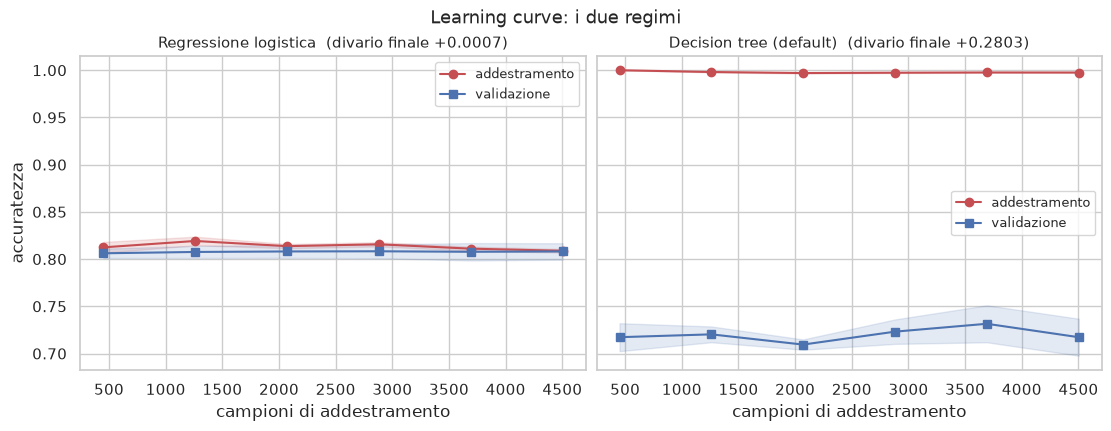


Decision tree potato (sezione 4): validazione 0.7934   divario finale +0.0187


In [9]:
# Learning curve: il DIVARIO fra le due curve misura la varianza, il LIVELLO a cui si
# stabilizzano misura il bias. Qui si mettono di fianco i due estremi — la regressione
# logistica con le curve sovrapposte e l'albero non potato che memorizza il training set —
# e in fondo lo stesso albero dopo la potatura, per far vedere che il divario si chiude.
esempi = [("Regressione logistica", finalisti["Regressione logistica"]),
          ("Decision tree (default)", modelli["Decision tree"])]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True, sharey=True)
for ax, (nome, stimatore) in zip(axes, esempi):
    n, tr, va = learning_curve(stimatore, X_tr, y_tr, cv=CV, n_jobs=-1,
                               train_sizes=np.linspace(.1, 1., 6), scoring="accuracy")
    ax.plot(n, tr.mean(1), "o-", color="#C44E52", label="addestramento")
    ax.fill_between(n, tr.mean(1) - tr.std(1), tr.mean(1) + tr.std(1), color="#C44E52", alpha=.15)
    ax.plot(n, va.mean(1), "s-", color="#4C72B0", label="validazione")
    ax.fill_between(n, va.mean(1) - va.std(1), va.mean(1) + va.std(1), color="#4C72B0", alpha=.15)
    ax.set_title(f"{nome}  (divario finale {tr.mean(1)[-1] - va.mean(1)[-1]:+.4f})", fontsize=11)
    ax.set_xlabel("campioni di addestramento"); ax.legend(fontsize=9)
    print(f"{nome}: validazione da {va.mean(1)[0]:.4f} (n={int(n[0])}) a {va.mean(1)[-1]:.4f} "
          f"(n={int(n[-1])})   divario finale {tr.mean(1)[-1] - va.mean(1)[-1]:+.4f}")
axes[0].set_ylabel("accuratezza")
fig.suptitle("Learning curve: i due regimi", fontsize=13)
plt.show()

# lo stesso albero, potato dalla sezione 4: quanto si chiude il divario
n, tr, va = learning_curve(finalisti["Decision tree"], X_tr, y_tr, cv=CV, n_jobs=-1,
                           train_sizes=np.linspace(.1, 1., 6), scoring="accuracy")
print(f"\nDecision tree potato (sezione 4): validazione {va.mean(1)[-1]:.4f}   "
      f"divario finale {tr.mean(1)[-1] - va.mean(1)[-1]:+.4f}")

**I due regimi, uno per pannello.**

La regressione logistica ha le curve **sovrapposte** (divario +0,0007): regime di *bias*, nessun
overfitting. Ed e' **piatta gia' da 450 campioni** — piu' dati non servirebbero, il limite e' altrove.

Il decision tree di default e' l'estremo opposto: divario **+0,2803**, cioe' quasi il 100% di
accuratezza in addestramento contro il 72% in validazione. Memorizza. La potatura della sezione 4
chiude il divario a +0,0187 e porta la validazione da 0,7173 a 0,7934: **7,6 punti guadagnati non
aggiungendo dati o feature, ma togliendo capacita' al modello.** E' il compromesso bias-varianza
misurato su un solo iperparametro.

## 7. Scelta del modello finale

Solo adesso, a scelte fatte, si apre il test set.

In [10]:
# Solo ORA si apre il test set, una volta sola, con i modelli gia' scelti. I criteri di
# scelta erano fissati prima: che la regressione logistica risulti prima anche qui e' una
# conferma, non la motivazione della scelta.
esiti = []
for nome, modello in finalisti.items():
    modello.fit(X_tr, y_tr)
    p = modello.predict(X_te)
    prob_te = modello.predict_proba(X_te)[:, 1]
    esiti.append({"modello": nome, "CV": round(cross_validate(modello, X_tr, y_tr, cv=CV,
                                                              scoring="accuracy", n_jobs=-1)["test_score"].mean(), 4),
                  "test: accuratezza": round(accuracy_score(y_te, p), 4),
                  "test: F1": round(f1_score(y_te, p), 4),
                  "test: ROC-AUC": round(roc_auc_score(y_te, prob_te), 4)})
pd.DataFrame(esiti).set_index("modello").sort_values("test: accuratezza", ascending=False)

,CV,test: accuratezza,test: F1,test: ROC-AUC
modello,,,,
Regressione logistica,0.8081,0.7925,0.8272,0.8485
k-NN,0.8079,0.7875,0.8240,0.8530
Naive Bayes gaussiano,0.7944,0.7790,0.8112,0.8408
Decision tree,0.7934,0.7747,0.8143,0.8404


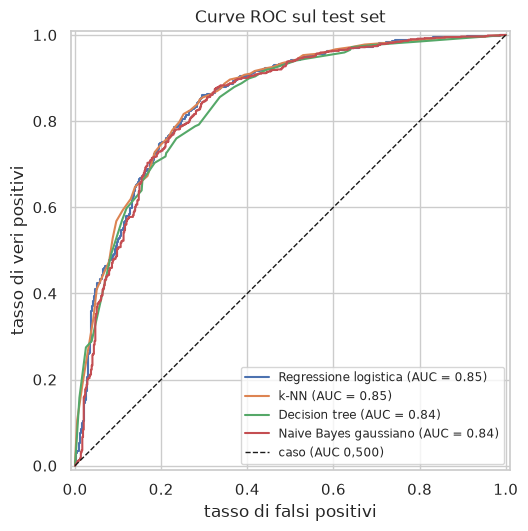

In [11]:
# Le curve ROC valutano il ranking delle probabilita', indipendentemente dalla soglia:
# due modelli con la stessa accuratezza possono ordinare gli studenti in modo diverso.
fig, ax = plt.subplots(figsize=(6, 5.2), constrained_layout=True)
for nome, modello in finalisti.items():
    RocCurveDisplay.from_estimator(modello, X_te, y_te, ax=ax, name=nome)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="caso (AUC 0,500)")
ax.set_xlabel("tasso di falsi positivi"); ax.set_ylabel("tasso di veri positivi")
ax.set_title("Curve ROC sul test set"); ax.legend(loc="lower right", fontsize=8.5)
plt.show()

**Modello scelto: regressione logistica** (`C = 0,1`, `StandardScaler`).

E' prima in **entrambe** le valutazioni: 0,8081 in cross-validation e 0,7925 sul test set. Il
k-NN ottimizzato le sta a due decimillesimi in CV e a mezzo punto sul test set, cioe' dentro il
rumore: fra i due non c'e' un vincitore statistico.

Il tie-break e' quindi la **parsimonia**, ed e' stato deciso prima di aprire il test set: un solo
iperparametro contro due, nessun overfitting, coefficienti leggibili, e un modello che non deve
tenere in memoria tutto il training set per predire. Che poi la regressione logistica risulti prima
anche sul test set e' una conferma, non la motivazione della scelta.

              precision    recall  f1-score   support

    prosegue     0.7864    0.6992    0.7402       595
   abbandona     0.7961    0.8608    0.8272       812

    accuracy                         0.7925      1407
   macro avg     0.7913    0.7800    0.7837      1407
weighted avg     0.7920    0.7925    0.7904      1407



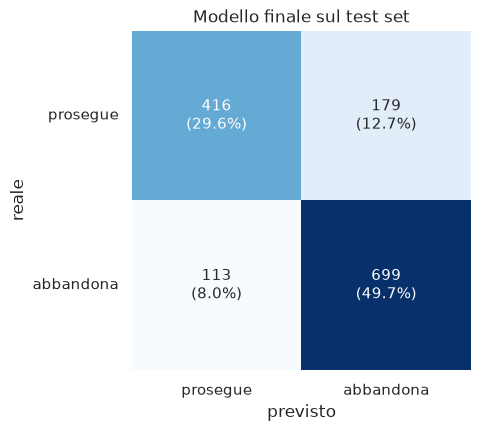

coefficienti (su feature standardizzate, quindi confrontabili fra loro):
n_attivita_distinte   -0.645
n_giorni_attivi       -0.644
n_azioni              -0.312
durata_giorni         -0.308
feature0_media        -0.299
feature2_media         0.038
feature1_media         0.141
feature3_media         0.203


In [12]:
# Il modello finale in dettaglio. I coefficienti sono confrontabili fra loro solo perche'
# le feature sono standardizzate — ma con correlazioni fino a 0,91 NON sono interpretabili
# singolarmente: il modello ha distribuito fra variabili quasi identiche un'unica quantita'
# di informazione.
finale = finalisti["Regressione logistica"]
pred = finale.predict(X_te)

print(classification_report(y_te, pred, target_names=["prosegue", "abbandona"], digits=4))

cm = confusion_matrix(y_te, pred)
fig, ax = plt.subplots(figsize=(6.0, 4.2), constrained_layout=True)
# conteggio e percentuale in una sola etichetta, costruita sull'intera matrice con le
# operazioni su stringhe di NumPy invece che con una doppia comprensione
etichette = np.char.add(cm.astype(str), np.char.mod("\n(%.1f%%)", cm / cm.sum() * 100))
sns.heatmap(cm, annot=etichette, fmt="", cmap="Blues", cbar=False, square=True, ax=ax,
            xticklabels=["prosegue", "abbandona"], yticklabels=["prosegue", "abbandona"],
            annot_kws={"size": 11})
ax.set_xlabel("previsto"); ax.set_ylabel("reale"); ax.set_title("Modello finale sul test set")
plt.setp(ax.get_yticklabels(), rotation=0)
plt.show()

coef = pd.Series(finale.named_steps["modello"].coef_[0], index=X.columns).sort_values()
print("coefficienti (su feature standardizzate, quindi confrontabili fra loro):")
print(coef.round(3).to_string())

Con correlazioni fino a 0,91 i coefficienti **non sono interpretabili singolarmente**: che
`n_attivita_distinte` pesi −0,645 e `n_azioni` −0,312 non significa che la prima conti il doppio, ma
che il modello ha distribuito fra due variabili quasi identiche un'unica quantita' di informazione.


## 8. Limiti

- **Il guadagno su Scikit-Learn e' piccolo**: da 0,7933 a 0,8081, circa una deviazione standard e
  mezza.
- **Il tetto e' nei dati.** I due modelli migliori si fermano entrambi a 0,808 partendo da famiglie
  opposte; la learning curve e' piatta da 450 campioni; tre feature su otto sono quasi costanti nel
  dataset originale e le altre cinque correlate fino a 0,91.
- **Tautologia.** Su una finestra iniziale l'AUC crolla a 0,535 (appendice del Task 1). Il 79% vale
  sul problema come e' formulato dal dataset, non come previsione a corso in corso.